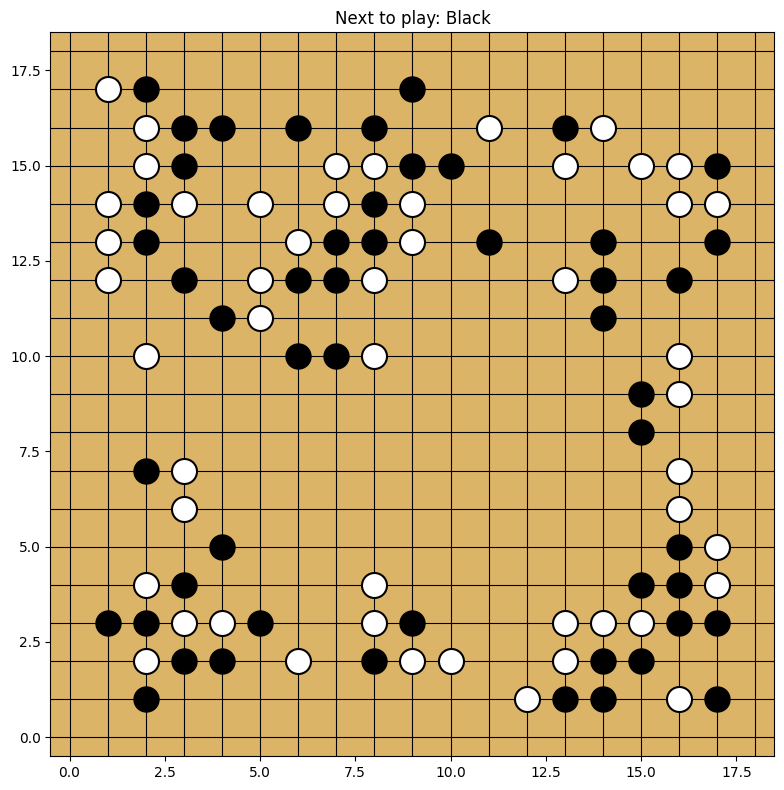

In [ ]:
import pandas as pd
import numpy as np


data = np.load("go_chunks/chunk_0000.npz")
df = pd.DataFrame({
    "next_to_go": data["next_to_go"],
    "winner": data["winner"]
})
df.to_csv("chunk_0000_check.csv", index=False)


import numpy as np
import matplotlib.pyplot as plt

data = np.load("go_chunks/chunk_0000.npz")

# Grab one position (e.g. position 100)
pos = data["positions"][100]  # shape (3, 19, 19)

black  = pos[0]  # 1 where black stone
white  = pos[1]  # 1 where white stone
player = data["next_to_go"][100]

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor("#DCB468")  # board color

# Draw grid
for i in range(19):
    ax.axhline(i, color="black", linewidth=0.8)
    ax.axvline(i, color="black", linewidth=0.8)

# Draw stones
for row in range(19):
    for col in range(19):
        if black[row, col]:
            ax.plot(col, row, 'o', markersize=18, color="black")
        elif white[row, col]:
            ax.plot(col, row, 'o', markersize=18, color="white",
                    markeredgecolor="black", markeredgewidth=1.5)

ax.set_xlim(-0.5, 18.5)
ax.set_ylim(-0.5, 18.5)
ax.set_title(f"Next to play: {'Black' if player == 1 else 'White'}")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("board_snapshot.png", dpi=150)
plt.show()